# **GreenRoute**
#### *Marouchka Heck, Chiara Bifulco, Nour Sarhini and Pamela Sampaa Afaki*

## **I. Introduction**

THINGS TO PIP INSTALL : 
MATPLOLIB

In [17]:
import matplotlib.pyplot as plt
!pip install pandas

## **III. Results**
---
### **Interactive molecule cards**
The home page of the GreenRoute website displays the available molecules: ibuprofen, artemisinin, sitagliptin and sertraline. These pharmaceutical molecules were selected because their synthesis pathways differ in terms of purpose, complexity, number of steps and environmental impact. This wide variation makes them particularly suitable for highlighting differences between greener and less sustainable approaches to pharmaceutical synthesis. 

💊 **Ibuprofen** is a widely used non-steroidal anti-inflammatory drug used to relieve pain, inflammation and fever. It is a classic study in green chemistry because its industrial synthesis has been significantly optimized over time.  
💊 **Artemisinin** is an antimalarial drug which has complex production pathways, making it useful for studying multi-step reaction efficiency.  
💊 **Sitagliptin** is a medication used in the treatment of type 2 diabetes. It is a useful case for studying how alternative synthetic strategies can reduce the number of steps and the efficiency.  
💊 **Sertraline** is a selective drug used to treat depression and anxiety disorders. It is a good example because comparing two industrial routes shows that efficiency is not solely determined by the number of steps.  

The molecule selection interface was designed using Streamlit. 
Before selection, each card displays the molecule name, its molecular formula, the number of synthesis pathways 
and the best atom economy value among all pathways (with a progress bar with dynamic color)

Each molecule card is generated using the function render_molecule_card() implemented in app.py. This function dynamically creates the card by displaying the molecule name, its molecular formula, the number of available synthesis pathways and the best atom economy value represented with a colored progress bar.

The pathway information displayed on the cards is calculated using the function get_molecule_summary(), which extracts the corresponding synthesis data from the calculated results dataset.
This allows the displayed values to automatically update if new synthesis pathways are added to the results file.

The cards are also interactive: when the user moves the cursor over a card, it slightly lifts and its shadow becomes stronger, improving the visual feedback and overall user experience. 

### **Molecular structure of the pharmaceutical compound**

After selecting a molecule, the user first sees its molecular structure.
RDKit’s Chem.MolFromSmiles() function was used to convert SMILES strings for the four molecules into chemically interpretable molecular structures.
To ensure visual consistency across the dataset, 2D coordinates were calculated for each structure. In the specific case of artemisinin, a modified RDKit approach is used in order to better represent its stereochemistry. 
The resulting molecular structures are then processed and exported as image files. When a molecule is selected by the user, the corresponding structure is shown individually. 
Inside app.py, the function get_molecule_image_path() is responsible for locating the correct molecular structure image from the SMILES folder before displaying it in the interface using st.image()

The resulting images are stored in the SMILES folder, used in the Streamlit interface, and also displayed in this Jupyter notebook using Matplotlib:

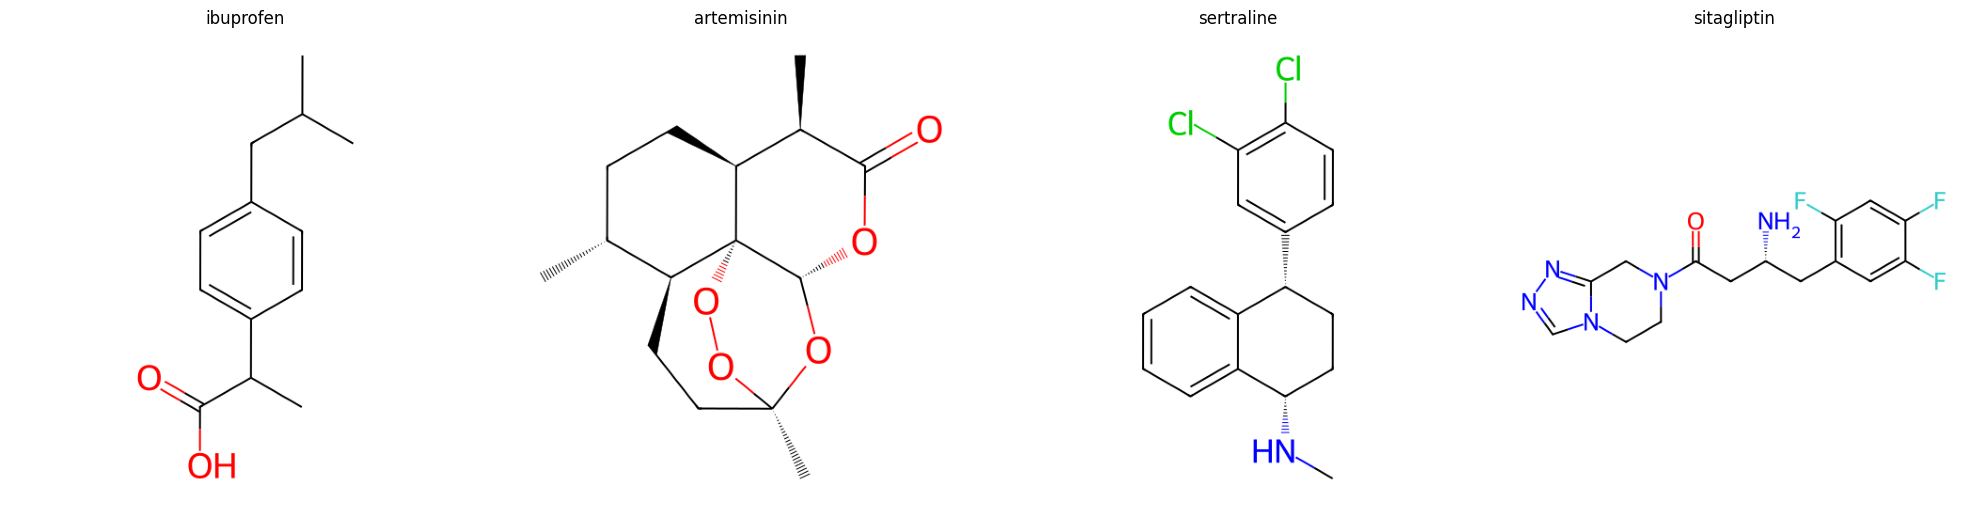

In [14]:
import os
from PIL import Image
import matplotlib.pyplot as plt

molecules = ["ibuprofen", "artemisinin", "sertraline", "sitagliptin"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, name in zip(axes, molecules):
    img_path = os.path.join("..", "src", "greenroute", "SMILES", f"{name}.png")

    if os.path.exists(img_path):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(name)
    else:
        ax.text(0.5, 0.5, "Missing", ha="center")

    ax.axis("off")

plt.tight_layout()
plt.show()

### **Pathway comparison**

After viewing the molecular structure of the pharmaceutical molecule, the user can scroll down to access the “Pathway comparison” table.


The Jupyter notebook reproduces the same pathway comparison logic as the Streamlit application by filtering the dataset, selecting relevant green chemistry metrics, and structuring them into a comparative table for analysis

In [28]:
import pandas as pd

results_df = pd.read_csv("../data/results/calculated_green_metrics.csv")
selected = "Sitagliptin"

mol_df = results_df[
    results_df["drug_name"].astype(str).str.lower() == selected.lower()
].copy()

print(f"Number of pathways for {selected}: {len(mol_df)}")

display_cols = [
    "route_name",
    "display_atom_economy_percent",
    "display_pmi",
    "display_e_factor",
    "display_overall_yield_percent",
    "display_number_of_steps",
    "average_hazard_score"
]
table_df = mol_df[display_cols]
table_df

Number of pathways for Sitagliptin: 2


,route_name,display_atom_economy_percent,display_pmi,display_e_factor,display_overall_yield_percent,display_number_of_steps,average_hazard_score
6,Merck 2nd-generation sitagliptin process,73.97,2.12,1.12,67.50,5,3.0
7,Merck/Codexis 3rd-generation biocatalytic sita...,90.01,1.28,0.28,76.28,2,1.6
